# Step 1 - Define the problem

In [1]:
GUess the servival rate of passenger in titanic dataset.

SyntaxError: invalid syntax (2468416235.py, line 1)

In [ ]:
#pip install xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split

#import XGBoost as xgb
#import LightGBM as lgb
import xgboost as xgb
import lightgbm as lgb

# Step 2 - Collect and Prepare Data(EDA)

## Step 2.1 - Understand the Dataset                                                      

In [3]:
Titanic_train=pd.read_csv('Titanic_train.csv')

In [4]:
Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanic_test=pd.read_csv('Titanic_test.csv')

In [6]:
Titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
Titanic_train.shape

(891, 12)

In [8]:
Titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
Titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
print(Titanic_test.shape)
print(Titanic_test.info())
print(Titanic_test.describe())

(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  332.000000  418.000000  418.000000  417.000000
mean   1100.500000    2.265550   30.272590    0.447368    0.392344   35.627188
std     120.810458    0.841838   1

### Step 2.1.2 check the distinct values in each column - Train set               

In [11]:
Titanic_train['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [12]:
Titanic_train.groupby('Pclass')['Fare'].agg(['max','min'])

,max,min
Pclass,,
1,512.3292,0.0
2,73.5000,0.0
3,69.5500,0.0


- As fare is less for class 3 so the people are more

- The dataset has only 3 classes. And class 3 has more passengers 

In [13]:
Titanic_train['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

- Males are more compare to females

In [14]:
Titanic_train['SibSp'].value_counts()        

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [15]:
Titanic_train['Parch'].value_counts()          

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [16]:
Titanic_train['Ticket'].value_counts()         

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64

In [17]:
Titanic_train['Fare'].value_counts()           

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

In [18]:
Titanic_train['Cabin'].value_counts()         

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [19]:
Titanic_train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [20]:
Titanic_train['Cabin'].nunique()

147

In [21]:
Titanic_train['Embarked'].value_counts()       

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

- More people has been boarded from S

In [22]:
Titanic_train['Survived'].value_counts()      

Survived
0    549
1    342
Name: count, dtype: int64

- servival rate is very low

In [23]:
Titanic_train['Survived'].unique()

array([0, 1])

### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

In [24]:
Titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- all the datatypes are as expected. No need to change

In [25]:
Titanic_train.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [26]:
Titanic_train.duplicated().any()

np.False_

##  Step 2.3 - Analyze Target Variable 

In [27]:
Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
Titanic_train['Survived'].value_counts()  

Survived
0    549
1    342
Name: count, dtype: int64

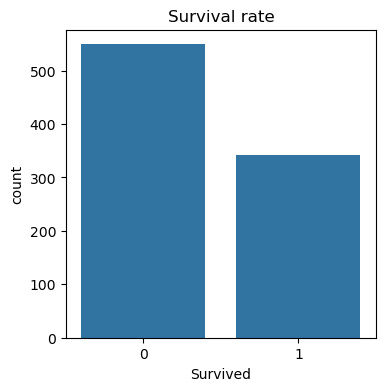

In [29]:
plt.figure(figsize=(4,4))
sns.countplot(Titanic_train,x='Survived')
plt.title('Survival rate')
plt.show()

- This dataset has imnbalance date

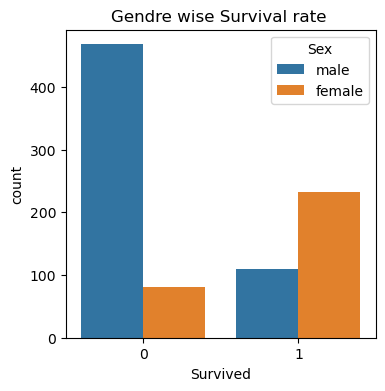

In [30]:
plt.figure(figsize=(4,4))
sns.countplot(Titanic_train,x='Survived',hue='Sex')
plt.title('Gendre wise Survival rate ')
plt.show()

- servival rate of females are more compare to female    

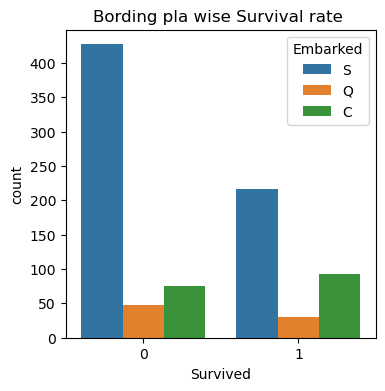

In [31]:
plt.figure(figsize=(4,4))
sns.countplot(Titanic_train,x='Survived',hue='Embarked')
plt.title('Bording pla wise Survival rate ')
plt.show()

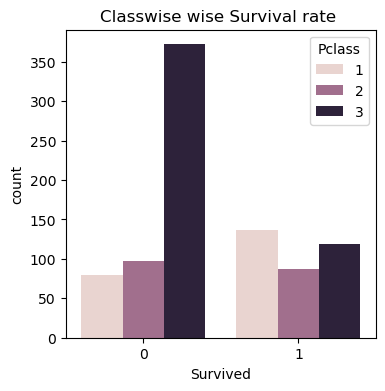

In [32]:
plt.figure(figsize=(4,4))
sns.countplot(Titanic_train,x='Survived',hue='Pclass')
plt.title('Classwise wise Survival rate ')
plt.show()

In [33]:
Titanic_train.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

## Step 2.4 - Univariate Analysis (Single Variable)  - see the distribution/count/histogram of any one variable

In [34]:
Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


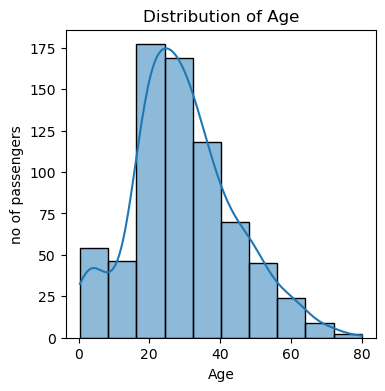

In [35]:
plt.figure(figsize=(4,4))
sns.histplot(data=Titanic_train,x='Age',bins=10,kde=True)
plt.title('Distribution of Age')
plt.ylabel('no of passengers')
plt.show()

- We can see that more passengers are from the age of 20 to 40

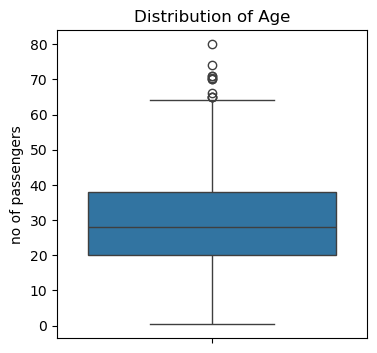

In [36]:
plt.figure(figsize=(4,4))
sns.boxplot(data=Titanic_train,y='Age')
plt.title('Distribution of Age')
plt.ylabel('no of passengers')
plt.show()

- from above plot we can see that age has few outliers. but those are not real outliers, may senior citizens are travelling

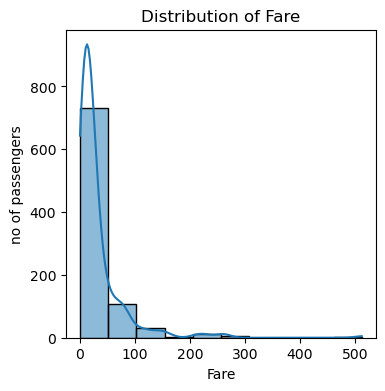

In [37]:
plt.figure(figsize=(4,4))
sns.histplot(data=Titanic_train,x='Fare',bins=10,kde=True)
plt.title('Distribution of Fare')
plt.ylabel('no of passengers')
plt.show()

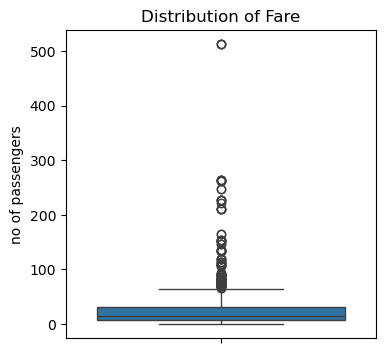

In [38]:
plt.figure(figsize=(4,4))
sns.boxplot(data=Titanic_train,y='Fare')
plt.title('Distribution of Fare')
plt.ylabel('no of passengers')
plt.show()

- most of the passengers are having fares between 0 to 100

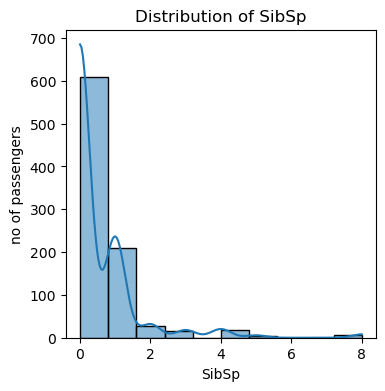

In [39]:
plt.figure(figsize=(4,4))
sns.histplot(data=Titanic_train,x='SibSp',bins=10,kde=True)
plt.title('Distribution of SibSp')
plt.ylabel('no of passengers')
plt.show()

- most of the passengers are travelling alone.
- Very few passengers are travelling with family

##  Step 2.6 - Bivariate/Multivariate Analysis – compare any feature with target variable.

In [40]:
Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


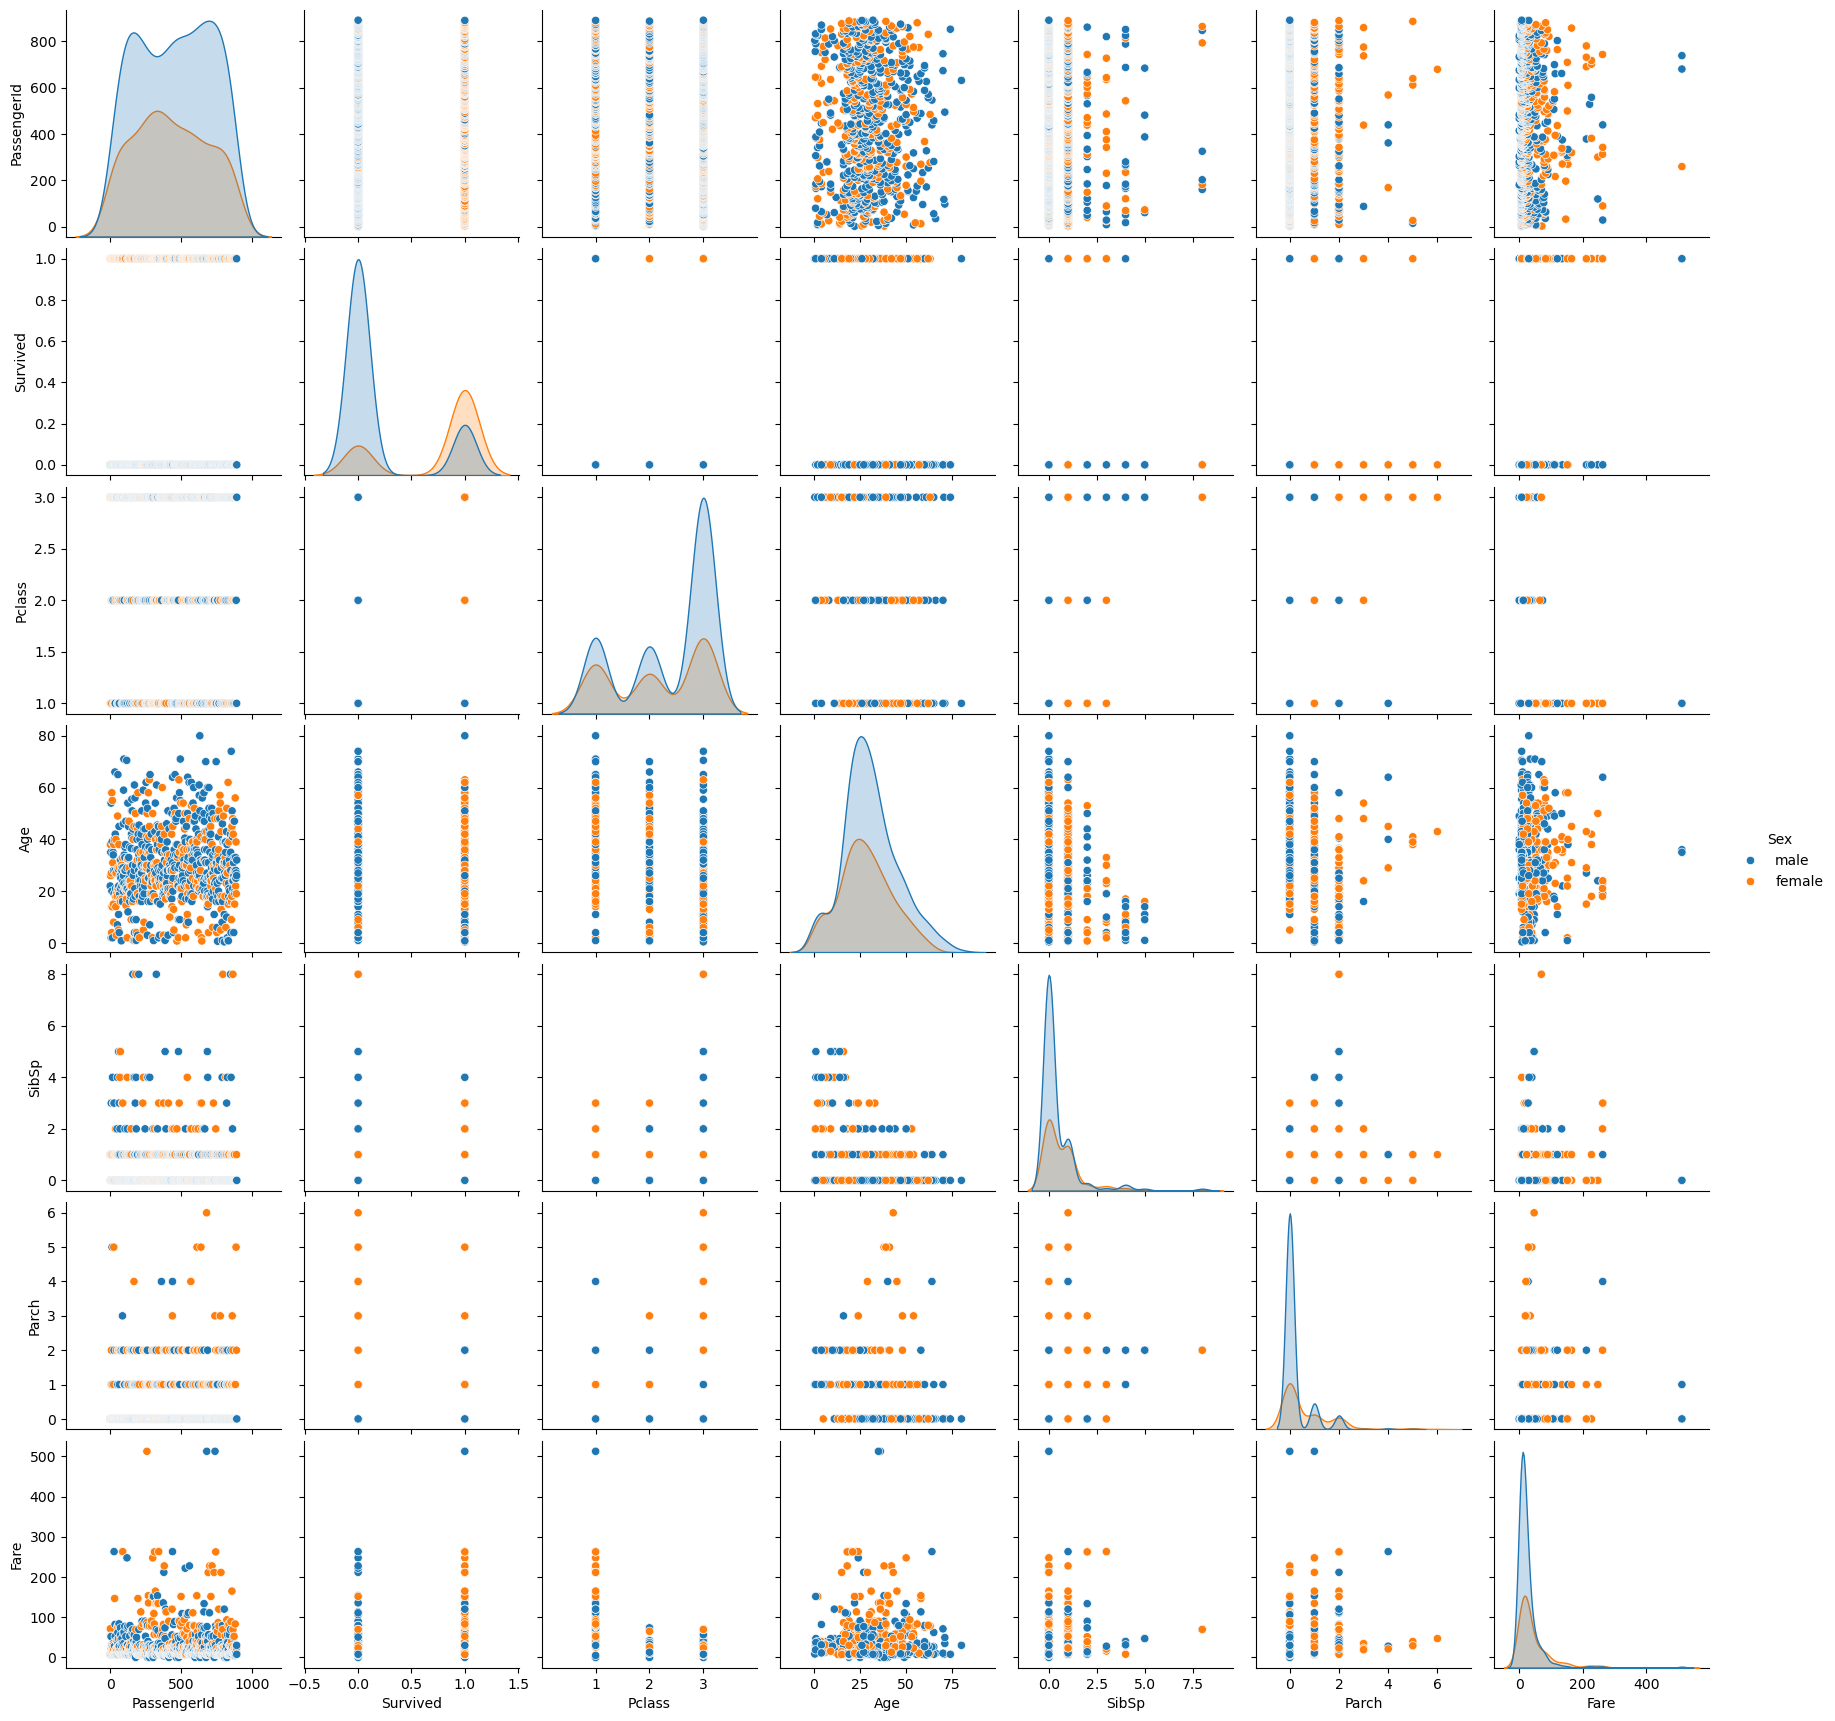

In [41]:
sns.pairplot(Titanic_train,hue='Sex')

In [42]:
Titanic_train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

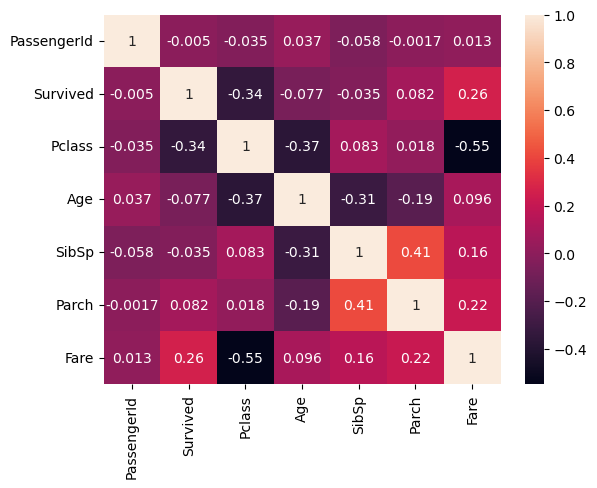

In [43]:
sns.heatmap(Titanic_train.corr(numeric_only=True),annot=True)

- By looking at the pairplot , corr and heatmap we can say that their is no direct relation of any feature on other feature

## Step 2.5 - Check for Missing Values 

In [44]:
Titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [45]:
age_mean=Titanic_train['Age'].mean()


In [46]:

print(age_mean)
    

29.69911764705882


In [47]:
Titanic_train_1=Titanic_train.copy()

In [48]:
Titanic_train_1['Age']=Titanic_train['Age'].fillna(age_mean)

In [49]:
Titanic_train_1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [50]:
Titanic_train_1.shape

(891, 12)

In [51]:
Titanic_train_1.drop('PassengerId',axis=1,inplace=True)

In [52]:
Titanic_train_1.drop('Cabin',axis=1,inplace=True)

In [53]:
Titanic_train_1.drop('Ticket',axis=1,inplace=True)

In [54]:
Titanic_train_1.drop('Name',axis=1,inplace=True)

In [55]:
Embarked_mode=Titanic_train_1['Embarked'].mode()[0]  

In [56]:
print(Embarked_mode)

S


In [57]:
Titanic_train_1['Embarked']=Titanic_train_1['Embarked'].fillna(Embarked_mode)

In [58]:
Titanic_train_1.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

##  Step 2.7 - Outlier Detection

In [59]:
Titanic_train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [60]:
Titanic_train_1.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


- Age

<Axes: ylabel='Age'>

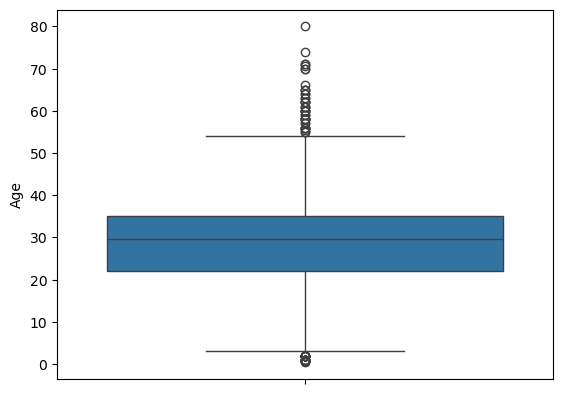

In [61]:
sns.boxplot(Titanic_train_1,y='Age')

<Figure size 400x400 with 0 Axes>

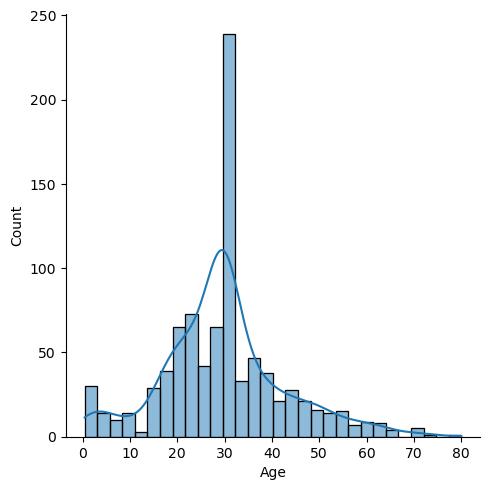

In [62]:
plt.figure(figsize=(4,4))
sns.displot(Titanic_train_1,x='Age',kde=True)
plt.show()

In [63]:
Titanic_train_1['Age'].max(),Titanic_train_1['Age'].min(),

(80.0, 0.42)

- though the graph shows gew outliers but real values are in the range of 0 to 100 which can be a valid range so no need to remove outliers.


- Fare

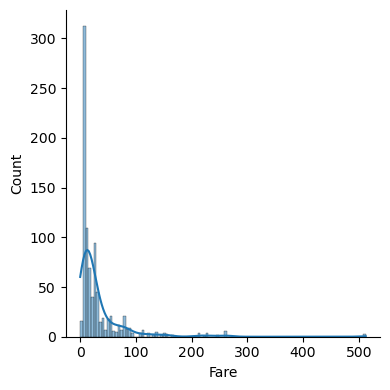

In [64]:
#plt.figure(figsize=(4,4)) - we should nnot use this for distplot

sns.displot(Titanic_train_1,x='Fare',kde=True, height=4, aspect=1)
plt.show()

<Axes: ylabel='Fare'>

<Figure size 400x400 with 0 Axes>

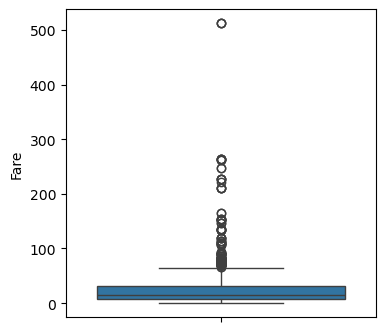

In [65]:
plt.figure(figsize=(4,4))
plt.figure(figsize=(4,4))
sns.boxplot(Titanic_train_1,y='Fare')

- as data is skewed we need to remove outlier by using the iqr method

In [66]:
q1=Titanic_train_1['Fare'].quantile(0.25)
q3=Titanic_train_1['Fare'].quantile(0.75)
print(q1,q3)

7.9104 31.0


In [67]:
IQR=q3-q1
print(IQR)

23.0896


In [68]:
Fare_lower_limit=q1-1.5*IQR
Fare_upper_limit=q1+1.5*IQR
print(Fare_lower_limit,Fare_upper_limit)

-26.724 42.5448


In [69]:
Titanic_train_1['Fare']=np.where(Titanic_train_1['Fare']<Fare_lower_limit,Fare_lower_limit,Titanic_train_1['Fare'])
Titanic_train_1['Fare']=np.where(Titanic_train_1['Fare']>Fare_upper_limit,Fare_upper_limit,Titanic_train_1['Fare'])

<Axes: ylabel='Fare'>

<Figure size 400x400 with 0 Axes>

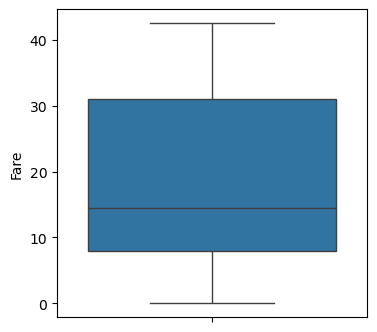

In [70]:
plt.figure(figsize=(4,4))
plt.figure(figsize=(4,4))
sns.boxplot(Titanic_train_1,y='Fare')

In [71]:
Titanic_train_1['Fare'].min(),Titanic_train_1['Fare'].max()

(0.0, 42.5448)

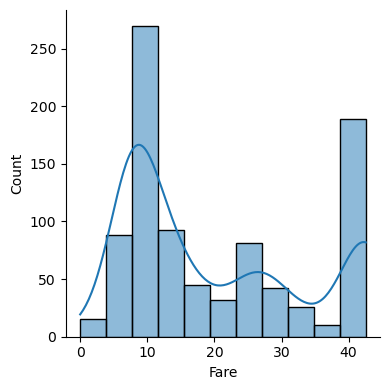

In [72]:

sns.displot(Titanic_train_1,x='Fare',kde=True, height=4, aspect=1)
plt.show()

## Step 2.8 – Encoding the values

In [73]:
Titanic_train_2=Titanic_train_1.copy()

In [74]:
Titanic_train_1.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,42.5448,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,42.5448,S
4,0,3,male,35.0,0,0,8.0500,S


- As features object feature does not have any ordering so we use one hot ecoding 

In [75]:
pd.get_dummies(Titanic_train_1['Sex'],drop_first=True).astype(int)

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [76]:
pd.get_dummies(Titanic_train_1['Embarked'],drop_first=True).astype(int)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [77]:
Titanic_train_2['Sex']=pd.get_dummies(Titanic_train_1['Sex'],drop_first=True).astype(int)

In [78]:
Titanic_train_2[['Boarding_Q','Boarding_S']]=pd.get_dummies(Titanic_train_2['Embarked'],drop_first=True).astype(int)

In [79]:
Titanic_train_2.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Boarding_Q,Boarding_S
0,0,3,1,22.0,1,0,7.2500,S,0,1
1,1,1,0,38.0,1,0,42.5448,C,0,0
2,1,3,0,26.0,0,0,7.9250,S,0,1
3,1,1,0,35.0,1,0,42.5448,S,0,1
4,0,3,1,35.0,0,0,8.0500,S,0,1


In [80]:
Titanic_train_2=Titanic_train_2.drop('Embarked',axis=1)

In [81]:
Titanic_train_2.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Boarding_Q,Boarding_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,42.5448,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,42.5448,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


##  Step 2.12 – Feature selection 

### 2.12.5) Filter Methods – Classfication / Regression

In [82]:
# Titanic_train_2.corr()['Survived'].abs().sort_values(ascending=False)

- BY using this we can find top N features

### 2.12.4) Select k best – Classification model

In [83]:
x=Titanic_train_2.iloc[:,1:]

In [84]:
y=Titanic_train_2.iloc[:,0:1]

In [85]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Boarding_Q,Boarding_S
0,3,1,22.0,1,0,7.2500,0,1
1,1,0,38.0,1,0,42.5448,0,0
2,3,0,26.0,0,0,7.9250,0,1
3,1,0,35.0,1,0,42.5448,0,1
4,3,1,35.0,0,0,8.0500,0,1


In [86]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [87]:
from sklearn.feature_selection import SelectKBest,chi2,f_classif,f_regression
clf_model=SelectKBest(k=5,score_func=f_classif)

In [88]:
selected_feature=clf_model.fit_transform(x,y)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [89]:
selected_feature

array([[ 3.    ,  1.    ,  0.    ,  7.25  ,  1.    ],
       [ 1.    ,  0.    ,  0.    , 42.5448,  0.    ],
       [ 3.    ,  0.    ,  0.    ,  7.925 ,  1.    ],
       ...,
       [ 3.    ,  0.    ,  2.    , 23.45  ,  1.    ],
       [ 1.    ,  1.    ,  0.    , 30.    ,  0.    ],
       [ 3.    ,  1.    ,  0.    ,  7.75  ,  0.    ]])

In [90]:
clf_model.feature_names_in_

array(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Boarding_Q',
       'Boarding_S'], dtype=object)

In [91]:
clf_model.get_feature_names_out()

array(['Pclass', 'Sex', 'Parch', 'Fare', 'Boarding_S'], dtype=object)

In [92]:
clf_model.scores_

array([1.15031272e+02, 3.72405724e+02, 4.35351609e+00, 1.11057220e+00,
       5.96346384e+00, 9.48413245e+01, 1.18463440e-02, 2.03744599e+01])

In [93]:
feature_imp=pd.DataFrame()
feature_imp['feature']=x.columns
feature_imp['score']=clf_model.scores_

In [94]:
feature_imp.sort_values(by='score',ascending=False)

,feature,score
1,Sex,372.405724
0,Pclass,115.031272
5,Fare,94.841325
7,Boarding_S,20.374460
4,Parch,5.963464
2,Age,4.353516
3,SibSp,1.110572
6,Boarding_Q,0.011846


- By using the filter method and selecekbest method we have received the priority in same order.
- BY looking at the above 2 result set we can soncsider (Sex,Pclass,Fare,Boarding_S,Parch,Age)

In [95]:
Titanic_train_3=Titanic_train_2[['Sex','Pclass','Fare','Boarding_S','Parch','Age']].copy()

In [96]:
Titanic_train_3.head()

,Sex,Pclass,Fare,Boarding_S,Parch,Age
0,1,3,7.2500,1,0,22.0
1,0,1,42.5448,0,0,38.0
2,0,3,7.9250,1,0,26.0
3,0,1,42.5448,1,0,35.0
4,1,3,8.0500,1,0,35.0


# Step 3 - Split the Data

##  Step 3.1 - find out independent and dependent variable

##  Step 3.2 split the data into X-train and Y-train

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
xx=Titanic_train_3.iloc[:,:]

In [99]:
yy=Titanic_train_2['Survived']

In [100]:
x_train,x_test,y_train,y_test=train_test_split(xx,yy,test_size=0.2,random_state=42)

In [101]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((712, 6), (179, 6), (712,), (179,))

### 3.2.2 Scale the dataset 

- Scaling is not required for dtree algorithm  models

### 3.2.3 Regularize the model

- No need regularize the model for Dtree

# Step 5 - Choose the Algorithm and Build the model

In [102]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

-- LGBclassifer

In [103]:
xgb_model=LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,force_row_wise=True
)

# Step 6 -Train the Model

In [105]:
xgb_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Total Bins 157
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier(force_row_wise=True)

# Step 7 - Evaluate the Model

## Step 6.1 - predict the values for training data(x_train)-yhat_train

In [106]:
xgb_y_hat_train=xgb_model.predict(x_train)

In [107]:
from sklearn.metrics import confusion_matrix,classification_report

In [108]:
xgb_train_cm=confusion_matrix(y_train,xgb_y_hat_train)
print(xgb_train_cm)

[[428  16]
 [ 33 235]]


In [109]:
xgb_train_cr=classification_report(y_train,xgb_y_hat_train)
print(xgb_train_cr)

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       444
           1       0.94      0.88      0.91       268

    accuracy                           0.93       712
   macro avg       0.93      0.92      0.93       712
weighted avg       0.93      0.93      0.93       712



- Accuracy of xgb with train data is 93%

In [110]:
xgb_y_hat_test=xgb_model.predict(x_test)

In [111]:
xgb_test_cm=confusion_matrix(y_test,xgb_y_hat_test)
print(xgb_test_cm)

[[91 14]
 [19 55]]


In [112]:
xgb_test_cr=classification_report(y_test,xgb_y_hat_test)
print(xgb_test_cr)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



- Accuracy of LGB with train data is 82%
- So the model is performing good with test and train both dataset

-- LightGBM

In [113]:
Lgb_model=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=0,
    num_leaves=31,force_row_wise=True
)

In [114]:
#Lgb_model.fit(x_train,y_train)
Lgb_model.fit(x_train,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "force_row_wise", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, force_row_wise=True, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [115]:
LGB_y_hat_train=Lgb_model.predict(x_train)

In [116]:
LGB_train_cm=confusion_matrix(y_train,LGB_y_hat_train)
LGB_TRain_cr=classification_report(y_train,LGB_y_hat_train)

In [117]:
print(LGB_train_cm)
print(LGB_TRain_cr)

[[437   7]
 [ 21 247]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       444
           1       0.97      0.92      0.95       268

    accuracy                           0.96       712
   macro avg       0.96      0.95      0.96       712
weighted avg       0.96      0.96      0.96       712



- LGB with train dataset accuracy 96%

-- With test data

In [119]:
LGB_y_hat_test=Lgb_model.predict(x_test)

In [120]:
LGB_test_cm=confusion_matrix(y_test,LGB_y_hat_test)
LGB_test_cr=classification_report(y_test,LGB_y_hat_test)

print(LGB_test_cm)
print(LGB_test_cr)

- LGB with train dataset accuracy 80%
- The both the model are performing good with the dataset

# Step 9 - Tune Hyperparameters

## Step 9.1 - Tune Hyperparameters - LGBM

In [121]:
from sklearn.model_selection import GridSearchCV

In [122]:
LGBM_params={'n_estimators':[100,150,200],
    'learning_rate':[0.1,0.2,0.01],
    'max_depth':[-1,5,10],
    'num_leaves':[31,40,50]}

In [123]:
LGBM_tuned_model=GridSearchCV(estimator=LGBMClassifier(),
                            param_grid=LGBM_params,
                        scoring='accuracy',
                             cv=2)

In [124]:
LGBM_tuned_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 134, number of negative: 222
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 116
[LightGBM] [Info] Number of data points in the train set: 356, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


GridSearchCV(cv=2, estimator=LGBMClassifier(),
             param_grid={'learning_rate': [0.1, 0.2, 0.01],
                         'max_depth': [-1, 5, 10],
                         'n_estimators': [100, 150, 200],
                         'num_leaves': [31, 40, 50]},
             scoring='accuracy')

In [125]:
LGBM_tuned_model.best_estimator_

LGBMClassifier(learning_rate=0.01, n_estimators=200)

In [126]:
LGBM_tuned_model.best_params_

{'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}

- Already i had used the same combination

## Step 9.2 - Tune Hyperparameters - XGB

In [127]:
XGBM_params={'n_estimators':[100,150,200],
    'learning_rate':[0.1,0.2,0.01],
    'max_depth':[0,5,10],
    'num_leaves':[31,40,50]}

In [128]:
XGB_tuned_model=GridSearchCV(estimator=XGBClassifier(),
                            param_grid=XGBM_params,
                        scoring='accuracy',
                             cv=2)

In [129]:
XGB_tuned_model.fit(x_train,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:28:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:28:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:28:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:28:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\U

GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.2, 0.01],
                         'max_depth': [0, 5, 10],
                         'n_estimators': [100, 150, 200],
                         'num_leaves': [31, 40, 50]},
             scoring='accuracy')

In [130]:
XGB_tuned_model.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=0,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_leaves=31, ...)

In [131]:
XGB_tuned_model.best_params_

{'learning_rate': 0.01, 'max_depth': 0, 'n_estimators': 150, 'num_leaves': 31}

In [132]:
Observations:
Gender (Sex) strongly impacts survival.
Passenger class (Pclass) is also highly influential.
Missing values in Age and Embarked were handled successfully.

SyntaxError: invalid syntax (2677901881.py, line 1)

In [ ]:
123534654t

In [ ]:
vkuyjfuyjfuyu